In [ ]:
# ── CELL 1: GPU + deps ────────────────────────────────────────────────────────
!nvidia-smi
!pip install pytorch-metric-learning -q
import torch
print('PyTorch:', torch.__version__)
print('CUDA:', torch.cuda.is_available())
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Tue Apr  7 23:35:42 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# ── CELL 2: Mount Drive ───────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')
import os
os.makedirs('/content/results', exist_ok=True)
os.makedirs('/content/results/checkpoints', exist_ok=True)
print('Ready.')

Mounted at /content/drive
Ready.


In [ ]:
# ── CELL 3: Dataset ───────────────────────────────────────────────────────────
import os, glob
candidates = glob.glob('/content/data/**/PartAnnotation', recursive=True)
if candidates:
    DATA_ROOT = candidates[0]
    print('Dataset already present:', DATA_ROOT)
else:
    KAGGLE_USERNAME = "PASTE_YOUR_USERNAME"
    KAGGLE_KEY      = "PASTE_YOUR_KEY"
    import json
    os.environ['KAGGLE_USERNAME'] = KAGGLE_USERNAME
    os.environ['KAGGLE_KEY']      = KAGGLE_KEY
    os.makedirs('/root/.kaggle', exist_ok=True)
    with open('/root/.kaggle/kaggle.json', 'w') as f:
        json.dump({'username': KAGGLE_USERNAME, 'key': KAGGLE_KEY}, f)
    os.chmod('/root/.kaggle/kaggle.json', 0o600)
    os.makedirs('/content/data', exist_ok=True)
    os.chdir('/content/data')
    !pip install kaggle -q
    !kaggle datasets download -d majdouline20/shapenetpart-dataset
    !unzip -q shapenetpart-dataset.zip
    os.chdir('/content')
    candidates = glob.glob('/content/data/**/PartAnnotation', recursive=True)
    DATA_ROOT = candidates[0]
print('DATA_ROOT:', DATA_ROOT)

Dataset URL: https://www.kaggle.com/datasets/majdouline20/shapenetpart-dataset
License(s): MIT
100% 1.02G/1.02G [00:08<00:00, 123MB/s]

DATA_ROOT: /content/data/PartAnnotation


In [ ]:
# ── CELL 4: Dataset loader ────────────────────────────────────────────────────
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

SYNSET_TO_CLASS = {
    '02691156':0,'02773838':1,'02954340':2,'02958343':3,'03001627':4,
    '03261776':5,'03467517':6,'03624134':7,'03636649':8,'03642806':9,
    '03790512':10,'03797390':11,'03948459':12,'04099429':13,'04225987':14,'04379243':15
}

def load_pts(path):
    pts = []
    with open(path) as f:
        for line in f:
            v = line.strip().split()
            if len(v) >= 3: pts.append([float(x) for x in v[:3]])
    return np.array(pts, dtype='float32')

def load_seg(path):
    segs = []
    with open(path) as f:
        for line in f:
            s = line.strip()
            if s: segs.append(int(s))
    return np.array(segs, dtype='int64')

class ShapeNet_coseg(Dataset):
    def __init__(self, partition='train', num_points=1024, obj_class=4,
                 data_root=None, train_ratio=0.8):
        self.num_points = num_points
        if data_root is None: data_root = DATA_ROOT
        target_syn = next((s for s,c in SYNSET_TO_CLASS.items() if c==obj_class), None)
        syn_dir = os.path.join(data_root, target_syn)
        pts_dir = os.path.join(syn_dir, 'points')
        seg_dir = os.path.join(syn_dir, 'points_label')
        all_ids = sorted([f[:-4] for f in os.listdir(pts_dir) if f.endswith('.pts')])
        seg_map = {}
        for dirpath, _, files in os.walk(seg_dir):
            for f in files:
                if f.endswith('.seg') and f[:-4] not in seg_map:
                    seg_map[f[:-4]] = os.path.join(dirpath, f)
        valid_ids = [i for i in all_ids if i in seg_map]
        np.random.seed(42)
        perm  = np.random.permutation(len(valid_ids))
        split = int(len(valid_ids) * train_ratio)
        chosen = [valid_ids[i] for i in (perm[:split] if partition=='train' else perm[split:])]
        self.samples = [(os.path.join(pts_dir,sid+'.pts'), seg_map[sid]) for sid in chosen]
        print(f'[ShapeNet] {partition}: {len(self.samples)} samples')

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        pc  = load_pts(self.samples[idx][0])
        seg = load_seg(self.samples[idx][1])
        n   = min(len(pc), len(seg))
        pc, seg = pc[:n], seg[:n]
        N   = len(pc)
        idx_s = np.random.choice(N, self.num_points, replace=(N < self.num_points))
        pc, seg = pc[idx_s], seg[idx_s]
        pc -= pc.mean(0); s = np.max(np.linalg.norm(pc, axis=1))
        if s > 0: pc /= s
        binary = (seg > seg.min()).astype('int64')
        return pc.astype('float32'), binary

ds_tmp = ShapeNet_coseg('test', 1024, 4)
print(f'Sample check: {ds_tmp[0][0].shape}')

[ShapeNet] test: 1356 samples
Sample check: (1024, 3)


In [ ]:
# ── CELL 5: Mutual Attention Sampling module ──────────────────────────────────
# Faithful reimplementation of NONLocalBlock1D_mutual from the original paper.
# Source: models/src/attention.py in https://github.com/jimmy15923/unsup_point_coseg

import torch
import torch.nn as nn
import torch.nn.functional as F

class MutualAttention(nn.Module):
    """
    Mutual Attention Sampling (MAS) — NONLocalBlock1D_mutual
    ─────────────────────────────────────────────────────────
    Each shape in the batch uses a DIFFERENT shape as the key/value.
    Specifically: key/value for sample i = features of sample (i-1) mod B.

    This forces the FG sampler to learn what is consistently foreground
    ACROSS different objects, which is the core co-segmentation idea.

    Input:  x  (B, C, N)  — per-point features
    Output: z  (B, C, N)  — attended features, same shape

    Internally:
      query  = current sample's features    (B, C, N)
      key    = shifted sample's features    (B, C, N)  [batch shifted by 1]
      value  = shifted sample's features    (B, C, N)  [same as key]

    Computes attention weights, then separates into:
      fg_attention_features: points that attend strongly to the other shape
      bg_attention_features: points that attend weakly  (1 - fg_attention)

    Concatenates both and projects back to input dimension.
    Adds residual connection: z = W([fg_feat, bg_feat]) + x
    """
    def __init__(self, in_channels, inter_channels=None, bn_layer=True):
        super().__init__()
        self.in_channels    = in_channels
        self.inter_channels = in_channels // 2 if inter_channels is None else inter_channels
        if self.inter_channels == 0:
            self.inter_channels = 1

        # Value projection (g)
        self.g     = nn.Conv1d(in_channels, self.inter_channels, 1)
        # Query projection (theta)
        self.theta = nn.Conv1d(in_channels, self.inter_channels, 1)
        # Key projection (phi)
        self.phi   = nn.Conv1d(in_channels, self.inter_channels, 1)

        # Output projection — input is inter_channels*2 because we concat fg+bg
        if bn_layer:
            self.W = nn.Sequential(
                nn.Conv1d(self.inter_channels * 2, in_channels, 1),
                nn.BatchNorm1d(in_channels)
            )
            nn.init.constant_(self.W[1].weight, 0)
            nn.init.constant_(self.W[1].bias,   0)
        else:
            self.W = nn.Conv1d(self.inter_channels * 2, in_channels, 1)
            nn.init.constant_(self.W.weight, 0)
            nn.init.constant_(self.W.bias,   0)

    def forward(self, x):
        """
        x: (B, C, N)
        """
        B, C, N = x.shape

        query = x
        # Shift batch by 1: sample i attends to sample (i-1) mod B
        # This is the cross-shape attention that makes it "mutual"
        key = value = torch.cat([query[-1].unsqueeze(0), query[:-1]], dim=0)

        # Project value: (B, inter_channels, N) → (B, N, inter_channels)
        v = self.g(value).permute(0, 2, 1)          # (B, N, inter_C)

        # Project query: (B, inter_channels, N) → (B, N, inter_channels)
        q = self.theta(query).permute(0, 2, 1)       # (B, N, inter_C)

        # Project key: (B, inter_channels, N)
        k = self.phi(key)                            # (B, inter_C, N)

        # Attention map: (B, N, N)
        attn = F.softmax(torch.matmul(q, k), dim=-1) # (B, N, N)

        # Per-point scalar attention weight: mean over query positions → (B, N)
        fg_weight = attn.mean(dim=1)                 # (B, N)
        bg_weight = 1.0 - fg_weight                  # (B, N)

        # Expand weights for matmul: (B, N, N)
        fg_w = fg_weight.unsqueeze(-1).expand(B, N, N)
        bg_w = bg_weight.unsqueeze(-1).expand(B, N, N)

        # Weighted value aggregation
        fg_feat = torch.matmul(fg_w, v)              # (B, N, inter_C)
        bg_feat = torch.matmul(bg_w, v)              # (B, N, inter_C)

        # Concatenate fg and bg attended features → (B, N, inter_C*2)
        y = torch.cat([fg_feat, bg_feat], dim=2)     # (B, N, inter_C*2)
        y = y.permute(0, 2, 1).contiguous()          # (B, inter_C*2, N)

        # Project back + residual
        z = self.W(y) + x                            # (B, C, N)
        return z


# Quick sanity check
x_test = torch.randn(4, 256, 64).to(DEVICE)
mas = MutualAttention(256).to(DEVICE)
out = mas(x_test)
print(f'MutualAttention: input {x_test.shape} → output {out.shape}')  # should be (4, 256, 64)
assert out.shape == x_test.shape, 'Shape mismatch!'
print('MutualAttention module OK.')

MutualAttention: input torch.Size([4, 256, 64]) → output torch.Size([4, 256, 64])
MutualAttention module OK.


In [ ]:
# ── CELL 6: Full model WITH MAS ───────────────────────────────────────────────
import torch.nn as nn
import torch.nn.functional as F
import copy

# ── DGCNN (unchanged) ─────────────────────────────────────────────────────────
def knn_graph(x, k):
    xt = x.permute(0,2,1)
    return torch.cdist(xt,xt).topk(k+1,dim=-1,largest=False).indices[:,:,1:]

def get_edge_feature(x, idx):
    B,D,N = x.shape; k = idx.shape[2]
    xt   = x.permute(0,2,1).contiguous()
    flat = idx.reshape(B,-1)
    nb   = torch.gather(xt,1,flat.unsqueeze(-1).expand(B,N*k,D)).view(B,N,k,D)
    xi   = xt.unsqueeze(2).expand(B,N,k,D)
    return torch.cat([xi, nb-xi], dim=-1).permute(0,3,1,2)

class EdgeConv(nn.Module):
    def __init__(self, in_ch, out_ch, k=20):
        super().__init__()
        self.k   = k
        self.net = nn.Sequential(
            nn.Conv2d(in_ch*2, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch), nn.LeakyReLU(0.2))
    def forward(self, x):
        return self.net(get_edge_feature(x, knn_graph(x, self.k))).max(dim=-1)[0]

class DGCNN(nn.Module):
    def __init__(self, k=20, emb_dim=512):
        super().__init__()
        self.ec1 = EdgeConv(3,   64,  k)
        self.ec2 = EdgeConv(64,  64,  k)
        self.ec3 = EdgeConv(64,  128, k)
        self.ec4 = EdgeConv(128, 256, k)
        self.proj = nn.Sequential(
            nn.Conv1d(512, emb_dim, 1, bias=False),
            nn.BatchNorm1d(emb_dim), nn.LeakyReLU(0.2), nn.Dropout(0.4))
    def forward(self, x):
        f1=self.ec1(x); f2=self.ec2(f1); f3=self.ec3(f2); f4=self.ec4(f3)
        return self.proj(torch.cat([f1,f2,f3,f4],dim=1))


# ── PointSampler WITH MAS ──────────────────────────────────────────────────────
class PointSamplerMAS(nn.Module):
    """
    PointSampler with Mutual Attention Sampling.

    Difference from original PointSampler:
      After the scoring MLP encodes features, a MutualAttention layer is applied
      BEFORE computing the final scores. This means each shape's sampler
      attends to a different shape's features when deciding which points to select.

    This directly mirrors the original paper's SampleNet which applies
    mutual_attention(y) after the PointNet encoder.
    """
    def __init__(self, in_dim, n_sample, use_mas=True):
        super().__init__()
        self.n       = n_sample
        self.use_mas = use_mas

        # Feature encoder (same as before)
        self.encoder = nn.Sequential(
            nn.Conv1d(in_dim, 256, 1), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Conv1d(256,    128, 1), nn.BatchNorm1d(128), nn.ReLU(),
        )

        # Mutual Attention applied on encoded features (128-dim)
        if use_mas:
            self.mutual_attn = MutualAttention(128, bn_layer=True)

        # Scoring head: one score per point
        self.score_head = nn.Conv1d(128, 1, 1)

    def forward(self, feats):
        """
        feats: (B, in_dim, N)
        returns: sampled_feats (B, in_dim, n_sample), indices, weights
        """
        B, D, N = feats.shape

        # Encode to 128-dim
        h = self.encoder(feats)          # (B, 128, N)

        # Apply mutual attention across batch
        if self.use_mas:
            h = self.mutual_attn(h)      # (B, 128, N) — cross-shape attention

        # Score each point
        scores = self.score_head(h).squeeze(1)           # (B, N)
        weights = torch.softmax(scores, dim=-1)          # (B, N)
        idx     = weights.topk(self.n, dim=-1).indices   # (B, n_sample)

        # Gather original features at selected indices
        idx_e = idx.unsqueeze(1).expand(B, D, self.n)
        sampled = torch.gather(feats, 2, idx_e)          # (B, D, n_sample)

        return sampled, idx, weights


# ── PartHead (unchanged) ───────────────────────────────────────────────────────
class PartHead(nn.Module):
    def __init__(self, in_dim, n_parts=2):
        super().__init__()
        self.fc = nn.Linear(in_dim, n_parts)
    def forward(self, feats):
        return torch.softmax(self.fc(feats.permute(0,2,1)), dim=-1)


# ── CoSegNet WITH MAS ──────────────────────────────────────────────────────────
class CoSegNetMAS(nn.Module):
    """
    Full co-segmentation network with Mutual Attention Sampling.
    use_mas=True  → with MAS (new baseline)
    use_mas=False → without MAS (original baseline for comparison)
    """
    def __init__(self, n_fg=256, n_bg=256, k=20, emb_dim=512, n_parts=2, use_mas=True):
        super().__init__()
        self.use_mas    = use_mas
        self.encoder    = DGCNN(k=k, emb_dim=emb_dim)
        self.fg_sampler = PointSamplerMAS(emb_dim, n_fg, use_mas=use_mas)
        self.bg_sampler = PointSamplerMAS(emb_dim, n_bg, use_mas=use_mas)
        self.part_head  = PartHead(emb_dim, n_parts)

    def forward(self, xyz):
        feats = self.encoder(xyz.permute(0,2,1))        # (B, D, N)
        fg_f, fg_idx, fg_w = self.fg_sampler(feats)
        bg_f, bg_idx, bg_w = self.bg_sampler(feats)
        probs = self.part_head(feats)                   # (B, N, 2)
        return feats, fg_f, bg_f, fg_w, bg_w, probs


# Sanity check
xyz_test = torch.randn(4, 32, 3).to(DEVICE)
net_test = CoSegNetMAS(n_fg=16, n_bg=16, use_mas=True).to(DEVICE)
feats, fg_f, bg_f, fg_w, bg_w, probs = net_test(xyz_test)
print(f'feats: {feats.shape}  fg_f: {fg_f.shape}  probs: {probs.shape}')
print('CoSegNetMAS (with MAS) OK.')

net_test2 = CoSegNetMAS(n_fg=16, n_bg=16, use_mas=False).to(DEVICE)
feats2, fg_f2, bg_f2, _, _, probs2 = net_test2(xyz_test)
print('CoSegNetMAS (without MAS) OK.')

feats: torch.Size([4, 512, 32])  fg_f: torch.Size([4, 512, 16])  probs: torch.Size([4, 32, 2])
CoSegNetMAS (with MAS) OK.
CoSegNetMAS (without MAS) OK.


In [ ]:
# ── CELL 7: Loss functions ─────────────────────────────────────────────────────
from pytorch_metric_learning.losses import NTXentLoss
ntxent = NTXentLoss(temperature=0.07)

def contrastive_loss(fg_f, bg_f):
    B,D,_ = fg_f.shape
    fg_obj = fg_f.mean(dim=2); bg_obj = bg_f.mean(dim=2)
    emb    = torch.cat([fg_obj, bg_obj], dim=0)
    labels = torch.cat([torch.arange(B), torch.arange(B)]).to(fg_f.device)
    try:    return ntxent(emb, labels)
    except: return torch.tensor(0.0, device=fg_f.device)

def repulsion_loss(fg_f, bg_f):
    return F.cosine_similarity(fg_f.mean(2), bg_f.mean(2), dim=-1).mean()

def spatial_loss_uniform(feats, xyz, k=10):
    B,D,N = feats.shape
    knn_idx = torch.cdist(xyz,xyz).topk(k+1,dim=-1,largest=False).indices[:,:,1:]
    ft   = feats.permute(0,2,1).contiguous()
    flat = knn_idx.reshape(B,-1)
    nb   = torch.gather(ft,1,flat.unsqueeze(-1).expand(B,N*k,D)).view(B,N,k,D)
    fi   = ft.unsqueeze(2).expand(B,N,k,D)
    return ((fi-nb)**2).sum(-1).mean()

def entropy_loss(probs):
    return -(probs * torch.log(probs + 1e-8)).sum(-1).mean()

def ema_consistency_loss(student_probs, teacher_probs):
    teacher_probs = teacher_probs.detach()
    eps = 1e-8
    return (teacher_probs * (torch.log(teacher_probs+eps) - torch.log(student_probs+eps))).sum(-1).mean()

print('Loss functions defined.')

Loss functions defined.


In [ ]:
# ── CELL 8: EMA + evaluate + config ───────────────────────────────────────────
from sklearn.metrics import jaccard_score, f1_score
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR

CFG = {
    'obj_class': 4, 'num_points': 1024, 'batch_size': 8,
    'n_fg': 256, 'n_bg': 256, 'n_parts': 2, 'emb_dim': 512, 'dgcnn_k': 20
}

def build_teacher(student):
    teacher = copy.deepcopy(student)
    for p in teacher.parameters(): p.requires_grad = False
    return teacher

@torch.no_grad()
def ema_update(teacher, student, alpha=0.999):
    for t_p, s_p in zip(teacher.parameters(), student.parameters()):
        t_p.data.mul_(alpha).add_(s_p.data, alpha=(1.0-alpha))

def evaluate(model, test_loader):
    model.eval()
    preds_all, labels_all = [], []
    with torch.no_grad():
        for xyz, lbl in test_loader:
            xyz = xyz.to(DEVICE); lbl = lbl.long()
            feats, fg_f, bg_f, _, _, _ = model(xyz)
            ft   = feats.permute(0,2,1)
            fg_p = fg_f.mean(2,keepdim=True).permute(0,2,1)
            bg_p = bg_f.mean(2,keepdim=True).permute(0,2,1)
            pred = ((ft-fg_p).norm(dim=-1) < (ft-bg_p).norm(dim=-1)).long()
            preds_all.append(pred.cpu().numpy().reshape(-1))
            labels_all.append(lbl.numpy().reshape(-1))
    y_pred = np.concatenate(preds_all)
    y_true = np.concatenate(labels_all)
    iou = jaccard_score(y_true, y_pred, average='binary', zero_division=0)
    f1  = f1_score(     y_true, y_pred, average='binary', zero_division=0)
    return iou, f1

print('EMA, evaluate, config defined.')

EMA, evaluate, config defined.


In [ ]:
# ── CELL 9: Training function (handles all configs) ───────────────────────────

def run(
    tag              = 'run',
    n_epochs         = 30,
    lr               = 3e-4,
    use_mas          = True,   # True = with MAS, False = original baseline
    lambda_sp        = 0.01,
    k_sp             = 10,
    lambda_ent       = 0.0001,
    use_ema          = False,
    ema_alpha        = 0.999,
    lambda_ema       = 0.1,
    ema_warmup       = 5,
):
    mas_str = 'MAS' if use_mas else 'no-MAS'
    ema_str = f'EMA α={ema_alpha} λ={lambda_ema}' if use_ema else 'no-EMA'
    print(f'\n{"="*60}')
    print(f'  {tag.upper()}')
    print(f'  {mas_str} | {ema_str} | {n_epochs} epochs')
    print(f'{"="*60}')

    train_loader = DataLoader(
        ShapeNet_coseg('train', CFG['num_points'], CFG['obj_class']),
        batch_size=CFG['batch_size'], shuffle=True, drop_last=True, num_workers=2)
    test_loader = DataLoader(
        ShapeNet_coseg('test', CFG['num_points'], CFG['obj_class']),
        batch_size=CFG['batch_size'], shuffle=False, num_workers=2)

    student = CoSegNetMAS(
        CFG['n_fg'], CFG['n_bg'], CFG['dgcnn_k'],
        CFG['emb_dim'], CFG['n_parts'], use_mas=use_mas
    ).to(DEVICE)

    teacher = build_teacher(student) if use_ema else None

    opt   = optim.Adam(student.parameters(), lr=lr, weight_decay=1e-4)
    sched = StepLR(opt, step_size=15, gamma=0.5)

    best_iou, best_f1 = 0.0, 0.0
    history = {'loss':[], 'iou':[], 'f1':[]}

    for epoch in range(n_epochs):
        student.train()
        if teacher: teacher.eval()
        ep_loss = 0.0

        for xyz, _ in train_loader:
            xyz = xyz.to(DEVICE)

            s_feats, s_fg_f, s_bg_f, _, _, s_probs = student(xyz)

            loss = (contrastive_loss(s_fg_f, s_bg_f)
                    + 0.5  * repulsion_loss(s_fg_f, s_bg_f)
                    + lambda_sp  * spatial_loss_uniform(s_feats, xyz, k_sp)
                    + lambda_ent * entropy_loss(s_probs))

            if use_ema and epoch >= ema_warmup:
                with torch.no_grad():
                    _, _, _, _, _, t_probs = teacher(xyz)
                loss = loss + lambda_ema * ema_consistency_loss(s_probs, t_probs)

            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(student.parameters(), 1.0)
            opt.step()

            if teacher:
                ema_update(teacher, student, alpha=ema_alpha)

            ep_loss += loss.item()

        sched.step()

        eval_model = teacher if (use_ema and teacher) else student
        iou, f1 = evaluate(eval_model, test_loader)
        avg_loss = ep_loss / len(train_loader)

        history['loss'].append(avg_loss)
        history['iou'].append(iou)
        history['f1'].append(f1)

        marker = ''
        if iou > best_iou:
            best_iou, best_f1 = iou, f1
            torch.save(eval_model.state_dict(),
                       f'/content/results/checkpoints/{tag}_best.pt')
            marker = '  --> Best'

        ema_flag = ' [warmup]' if (use_ema and epoch < ema_warmup) else ''
        print(f'[{tag}] E{epoch:02d} | loss {avg_loss:.4f} | '
              f'IOU {iou:.4f} | F1 {f1:.4f}{marker}{ema_flag}')

    print(f'DONE [{tag}]  Best IOU={best_iou:.4f}  F1={best_f1:.4f}')
    return history, best_iou, best_f1

print('run() defined.')

run() defined.


In [ ]:
# ── CELL 10: Baseline (no MAS, no EMA) ───────────────────────────────────────
h_base, iou_base, f1_base = run(
    tag='baseline_no_mas',
    n_epochs=30, use_mas=False, use_ema=False
)
print(f'Baseline (no MAS): IOU={iou_base:.4f}  F1={f1_base:.4f}')


  BASELINE_NO_MAS
  no-MAS | no-EMA | 30 epochs
[ShapeNet] train: 5422 samples
[ShapeNet] test: 1356 samples
[baseline_no_mas] E00 | loss 1.3636 | IOU 0.3550 | F1 0.5240  --> Best
[baseline_no_mas] E01 | loss 0.8278 | IOU 0.2704 | F1 0.4257
[baseline_no_mas] E02 | loss 0.7430 | IOU 0.2379 | F1 0.3843
[baseline_no_mas] E03 | loss 0.6453 | IOU 0.2332 | F1 0.3782
[baseline_no_mas] E04 | loss 0.5944 | IOU 0.2907 | F1 0.4504
[baseline_no_mas] E05 | loss 0.5490 | IOU 0.2067 | F1 0.3426
[baseline_no_mas] E06 | loss 0.5257 | IOU 0.3033 | F1 0.4654
[baseline_no_mas] E07 | loss 0.5083 | IOU 0.3394 | F1 0.5068
[baseline_no_mas] E08 | loss 0.4936 | IOU 0.3027 | F1 0.4648
[baseline_no_mas] E09 | loss 0.4833 | IOU 0.3095 | F1 0.4727
[baseline_no_mas] E10 | loss 0.4653 | IOU 0.3067 | F1 0.4694
[baseline_no_mas] E11 | loss 0.4600 | IOU 0.2200 | F1 0.3606
[baseline_no_mas] E12 | loss 0.4598 | IOU 0.1711 | F1 0.2922
[baseline_no_mas] E13 | loss 0.4440 | IOU 0.2538 | F1 0.4049
[baseline_no_mas] E14 | lo

In [ ]:
# ── CELL 11: MAS only (no EMA) ────────────────────────────────────────────────
h_mas, iou_mas, f1_mas = run(
    tag='mas_no_ema',
    n_epochs=30, use_mas=True, use_ema=False
)
print(f'MAS only (no EMA): IOU={iou_mas:.4f}  F1={f1_mas:.4f}')


  MAS_NO_EMA
  MAS | no-EMA | 30 epochs
[ShapeNet] train: 5422 samples
[ShapeNet] test: 1356 samples
[mas_no_ema] E00 | loss 1.5722 | IOU 0.2684 | F1 0.4232  --> Best
[mas_no_ema] E01 | loss 0.8974 | IOU 0.2419 | F1 0.3895
[mas_no_ema] E02 | loss 0.7561 | IOU 0.2381 | F1 0.3846
[mas_no_ema] E03 | loss 0.6739 | IOU 0.2686 | F1 0.4235  --> Best
[mas_no_ema] E04 | loss 0.6189 | IOU 0.3246 | F1 0.4901  --> Best
[mas_no_ema] E05 | loss 0.5789 | IOU 0.2728 | F1 0.4287
[mas_no_ema] E06 | loss 0.5505 | IOU 0.2501 | F1 0.4001
[mas_no_ema] E07 | loss 0.5246 | IOU 0.3763 | F1 0.5468  --> Best
[mas_no_ema] E08 | loss 0.5052 | IOU 0.2075 | F1 0.3437
[mas_no_ema] E09 | loss 0.4919 | IOU 0.2390 | F1 0.3858
[mas_no_ema] E10 | loss 0.4929 | IOU 0.2127 | F1 0.3508
[mas_no_ema] E11 | loss 0.4739 | IOU 0.1841 | F1 0.3110
[mas_no_ema] E12 | loss 0.4682 | IOU 0.2438 | F1 0.3921
[mas_no_ema] E13 | loss 0.4579 | IOU 0.2350 | F1 0.3805
[mas_no_ema] E14 | loss 0.4543 | IOU 0.2983 | F1 0.4595
[mas_no_ema] E15 |

In [ ]:
# ── CELL 12: MAS + EMA ────────────────────────────────────────────────────────
h_mas_ema, iou_mas_ema, f1_mas_ema = run(
    tag='mas_ema',
    n_epochs=30, use_mas=True,
    use_ema=True, ema_alpha=0.999, lambda_ema=0.1, ema_warmup=5
)
print(f'MAS + EMA: IOU={iou_mas_ema:.4f}  F1={f1_mas_ema:.4f}')


  MAS_EMA
  MAS | EMA α=0.999 λ=0.1 | 30 epochs
[ShapeNet] train: 5422 samples
[ShapeNet] test: 1356 samples
[mas_ema] E00 | loss 1.6168 | IOU 0.4711 | F1 0.6405  --> Best [warmup]
[mas_ema] E01 | loss 0.8946 | IOU 0.4644 | F1 0.6342 [warmup]
[mas_ema] E02 | loss 0.7627 | IOU 0.4500 | F1 0.6207 [warmup]
[mas_ema] E03 | loss 0.6945 | IOU 0.4291 | F1 0.6006 [warmup]
[mas_ema] E04 | loss 0.6292 | IOU 0.4147 | F1 0.5863 [warmup]
[mas_ema] E05 | loss 0.5941 | IOU 0.4254 | F1 0.5968
[mas_ema] E06 | loss 0.5580 | IOU 0.4420 | F1 0.6130
[mas_ema] E07 | loss 0.5301 | IOU 0.4384 | F1 0.6095
[mas_ema] E08 | loss 0.5138 | IOU 0.4476 | F1 0.6184
[mas_ema] E09 | loss 0.4984 | IOU 0.4458 | F1 0.6167
[mas_ema] E10 | loss 0.4910 | IOU 0.4489 | F1 0.6196
[mas_ema] E11 | loss 0.4805 | IOU 0.4443 | F1 0.6152
[mas_ema] E12 | loss 0.4711 | IOU 0.4278 | F1 0.5993
[mas_ema] E13 | loss 0.4578 | IOU 0.4408 | F1 0.6119
[mas_ema] E14 | loss 0.4614 | IOU 0.4530 | F1 0.6235
[mas_ema] E15 | loss 0.4252 | IOU 0.4616

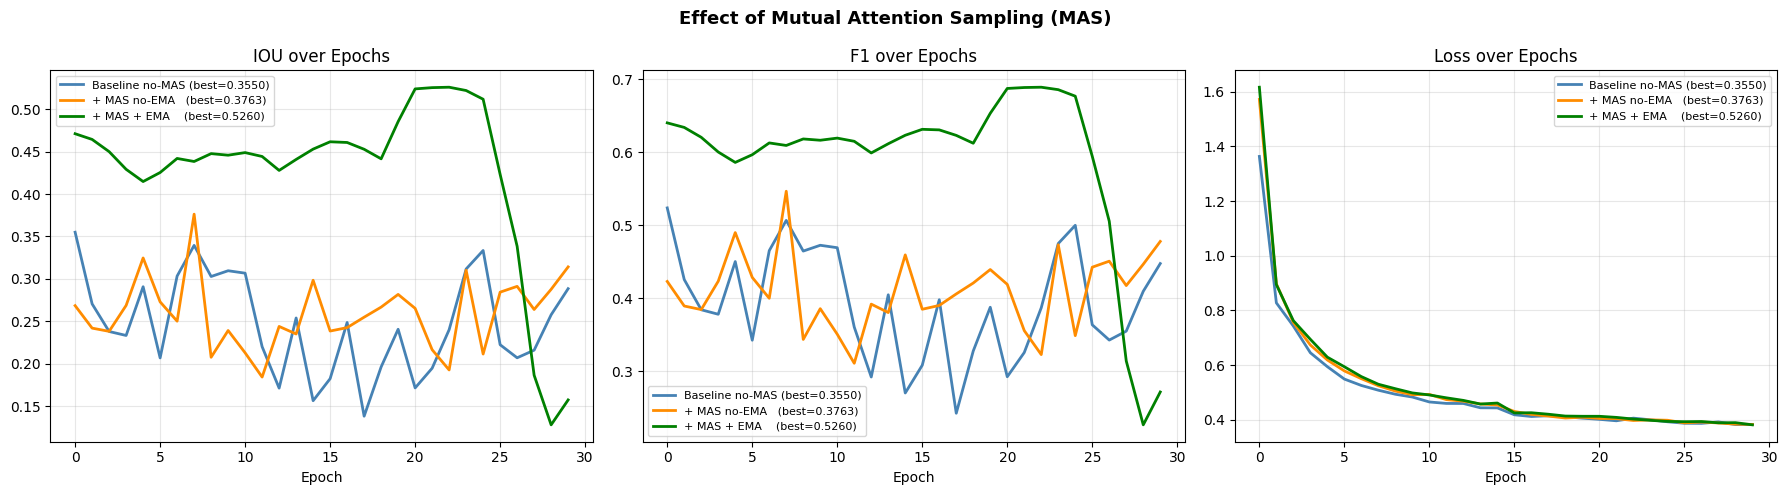


Stability (IOU variance, lower = more stable):
  Baseline             variance=0.003232
  MAS                  variance=0.001679
  MAS+EMA              variance=0.009555


In [ ]:
# ── CELL 13: Complete comparison plots ───────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Effect of Mutual Attention Sampling (MAS)', fontsize=13, fontweight='bold')

labels_plot = [
    (h_base,    f'Baseline no-MAS (best={iou_base:.4f})',    'steelblue'),
    (h_mas,     f'+ MAS no-EMA   (best={iou_mas:.4f})',      'darkorange'),
    (h_mas_ema, f'+ MAS + EMA    (best={iou_mas_ema:.4f})',  'green'),
]

for ax, key, title in zip(axes, ['iou','f1','loss'], ['IOU','F1','Loss']):
    for h, label, col in labels_plot:
        ax.plot(h[key], label=label, color=col, lw=2)
    ax.set_title(f'{title} over Epochs')
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/results/mas_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Stability analysis
print('\nStability (IOU variance, lower = more stable):')
for h, name in [(h_base,'Baseline'), (h_mas,'MAS'), (h_mas_ema,'MAS+EMA')]:
    v = np.var(h['iou'])
    print(f'  {name:<20} variance={v:.6f}')

In [ ]:
# ── CELL 14: Complete final summary ───────────────────────────────────────────
print('\n' + '='*65)
print('  COMPLETE RESULTS — MAS INTEGRATION')
print('  ShapeNet Part (Chair) | DGCNN + PointSamplerMAS | 1024 pts')
print('='*65)

# Historical results (from previous sessions)
historical = [
    ('Baseline (no MAS, no EMA)',           0.3379, 0.5052),
    ('+ Spatial + Entropy',                 0.3832, 0.5541),
    ('+ EMA standard KL',                   0.6086, 0.7567),
]

# This session
this_session = [
    ('Baseline no-MAS (reproduced)',         iou_base,    f1_base),
    ('+ MAS (no EMA)',                       iou_mas,     f1_mas),
    ('+ MAS + EMA',                          iou_mas_ema, f1_mas_ema),
]

print(f'\n  Historical (saved from previous sessions):')
print(f'  {"Method":<45} {"IOU":>8} {"F1":>8}')
print('  ' + '-'*63)
for name, iou, f1 in historical:
    print(f'  {name:<45} {iou:>8.4f} {f1:>8.4f}')

print(f'\n  This session (30 epochs each):')
print(f'  {"Method":<45} {"IOU":>8} {"F1":>8}')
print('  ' + '-'*63)
best_iou_session = max(r[1] for r in this_session)
for name, iou, f1 in this_session:
    marker = '  <- best' if iou == best_iou_session else ''
    print(f'  {name:<45} {iou:>8.4f} {f1:>8.4f}{marker}')

print('\n' + '='*65)

delta_mas     = iou_mas     - iou_base
delta_mas_ema = iou_mas_ema - iou_base
print(f'\n  MAS contribution:       {delta_mas:+.4f} IOU over baseline')
print(f'  MAS + EMA contribution: {delta_mas_ema:+.4f} IOU over baseline')


  COMPLETE RESULTS — MAS INTEGRATION
  ShapeNet Part (Chair) | DGCNN + PointSamplerMAS | 1024 pts

  Historical (saved from previous sessions):
  Method                                             IOU       F1
  ---------------------------------------------------------------
  Baseline (no MAS, no EMA)                       0.3379   0.5052
  + Spatial + Entropy                             0.3832   0.5541
  + EMA standard KL                               0.6086   0.7567

  This session (30 epochs each):
  Method                                             IOU       F1
  ---------------------------------------------------------------
  Baseline no-MAS (reproduced)                    0.3550   0.5240
  + MAS (no EMA)                                  0.3763   0.5468
  + MAS + EMA                                     0.5260   0.6894  <- best


  MAS contribution:       +0.0213 IOU over baseline
  MAS + EMA contribution: +0.1710 IOU over baseline


In [ ]:
# ── CELL 15: Save to Drive ────────────────────────────────────────────────────
import shutil
dest = '/content/drive/MyDrive/BTP_MAS_results'
os.makedirs(dest, exist_ok=True)
shutil.copytree('/content/results', dest, dirs_exist_ok=True)
print('Saved to Drive:', dest)
for f in sorted(os.listdir('/content/results')):
    if f.endswith('.png'): print(' ', f)

Saved to Drive: /content/drive/MyDrive/BTP_MAS_results
  mas_comparison.png
